In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('./data/sales.csv', encoding='cp949')

In [3]:
df.head()

,ORDERID,PURCHASE_PAGE,CITY,CUSTOMER_TYPE,GENDER,PRODUCT_TYPE,UNIT_PRICE,QUANTITY,MILEAGE,TOTAL_PRICE,DATE,PURCHASE_TIME,PAYMENT,COGS,GROSS_MARGIN_PERCENTAGE,GROSS_INCOME,RATING
0,750-67-8428,A,Seoul,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Samsungpay,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Gyeonggi,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Naverpay,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Seoul,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Seoul,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Samsungpay,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Seoul,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Samsungpay,604.17,4.761905,30.2085,0.0


### matplotlib  

In [4]:
import matplotlib.pyplot as plt 

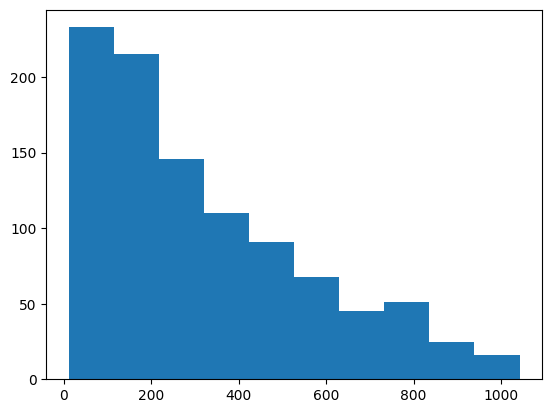

In [5]:
plt.hist(df['TOTAL_PRICE'])
plt.show()

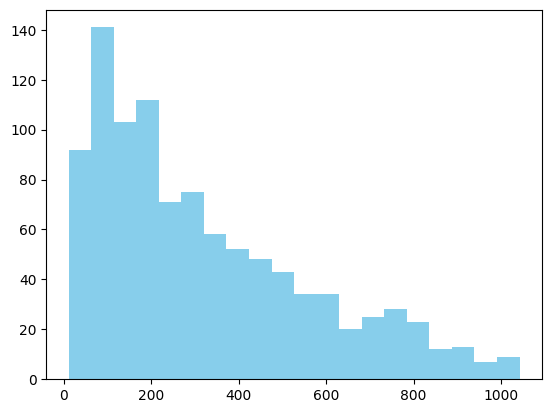

In [6]:
plt.hist(df['TOTAL_PRICE'], bins=20, color='skyblue')
plt.show()

In [15]:
# 겹쳐서 그릴것이기 때문에 투명도를 설정해주는게 좋음  
man_price = df[df['GENDER'] == 'Male']['TOTAL_PRICE']
woman_price = df[df['GENDER'] == 'Female']['TOTAL_PRICE']
print(man_price.head(5))
print(woman_price.head(5))

2     340.5255
3     489.0480
4     634.3785
5     627.6165
11    107.1420
Name: TOTAL_PRICE, dtype: float64
0    548.9715
1     80.2200
6    433.6920
7    772.3800
8     76.1460
Name: TOTAL_PRICE, dtype: float64


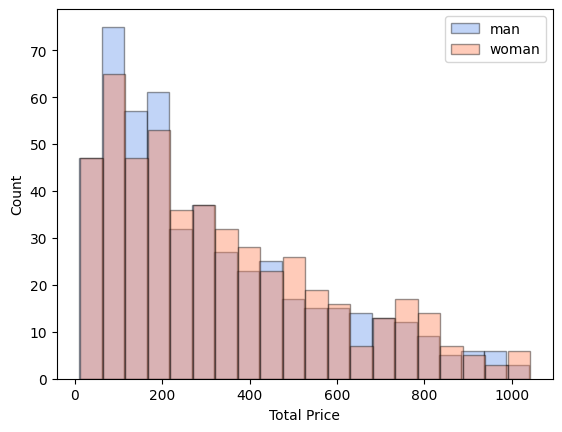

In [12]:
plt.hist(man_price, bins=20, color='cornflowerblue', alpha=0.4, edgecolor='black', linewidth=1, label='man')
plt.hist(woman_price, bins=20, color='coral', alpha=0.4, edgecolor='black', linewidth=1, label='woman')  
plt.xlabel('Total Price')
plt.ylabel('Count')
plt.legend()
plt.show()

In [16]:
category_counts = df['CITY'].value_counts()
print(category_counts)

CITY
Seoul       340
Incheon     332
Gyeonggi    328
Name: count, dtype: int64


In [17]:
city_idx = category_counts.index
print(city_idx)

Index(['Seoul', 'Incheon', 'Gyeonggi'], dtype='object', name='CITY')


In [19]:
colors = ['red', 'blue', 'orange']

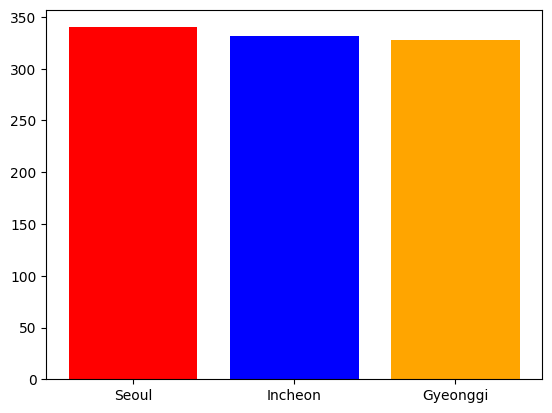

In [20]:
plt.bar(x = city_idx, height=category_counts, color=colors)
plt.show()

In [21]:
city_gender = pd.crosstab(df['CITY'], df['GENDER'])
city_gender

GENDER,Female,Male
CITY,,
Gyeonggi,178,150
Incheon,162,170
Seoul,161,179


In [22]:
city_gender.index

Index(['Gyeonggi', 'Incheon', 'Seoul'], dtype='object', name='CITY')

In [23]:
city_gender.columns

Index(['Female', 'Male'], dtype='object', name='GENDER')

In [24]:
city_gender['Male']

CITY
Gyeonggi    150
Incheon     170
Seoul       179
Name: Male, dtype: int64

In [25]:
city_gender['Female']

CITY
Gyeonggi    178
Incheon     162
Seoul       161
Name: Female, dtype: int64

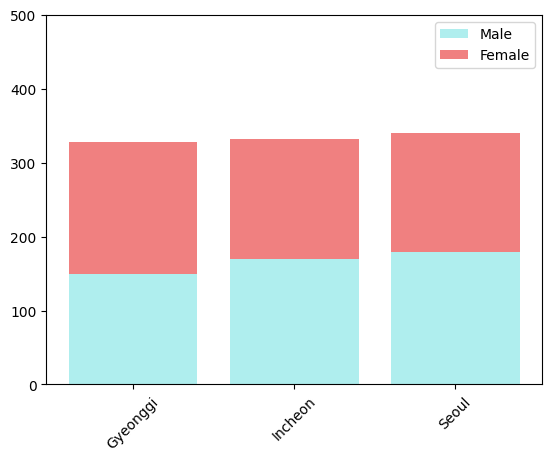

In [28]:
plt.bar(x=city_gender.index, height=city_gender['Male'], color='paleturquoise', label='Male')
plt.bar(x=city_gender.index, height=city_gender['Female'], bottom=city_gender['Male'], color='lightcoral', label='Female')
plt.ylim(0, 500)
plt.xticks(rotation=45)
plt.legend()
plt.show()

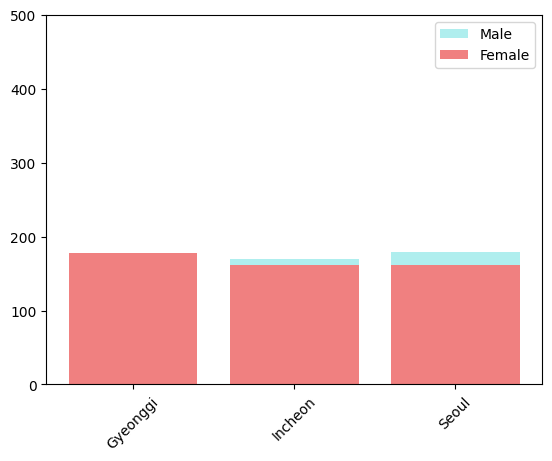

In [29]:
plt.bar(x=city_gender.index, height=city_gender['Male'], color='paleturquoise', label='Male')
plt.bar(x=city_gender.index, height=city_gender['Female'], color='lightcoral', label='Female')
plt.ylim(0, 500)
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [35]:
city_price = df.groupby('CITY')['TOTAL_PRICE'].mean()
city_price

CITY
Gyeonggi    337.099715
Incheon     319.872506
Seoul       312.354031
Name: TOTAL_PRICE, dtype: float64

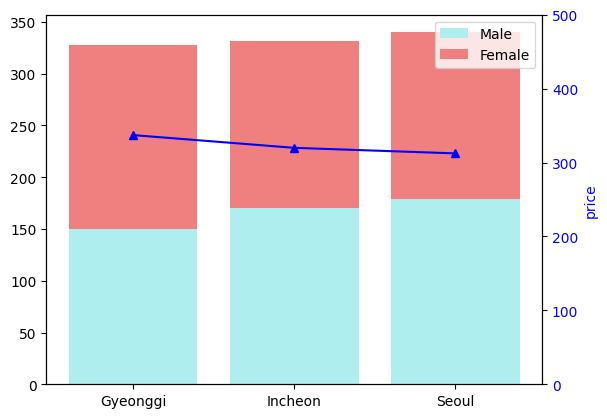

In [41]:
fig, ax1 = plt.subplots()
ax1.bar(x=city_gender.index, height=city_gender['Male'], color='paleturquoise', label='Male')
ax1.bar(x=city_gender.index, height=city_gender['Female'], bottom=city_gender['Male'], color='lightcoral', label='Female')
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(city_gender.index, city_price, '^-', color='b')
ax2.set_ylabel('price', color='b')
ax2.tick_params(axis='y', labelcolor='b')

plt.ylim(0, 500)
plt.xticks(rotation=45)
plt.show()

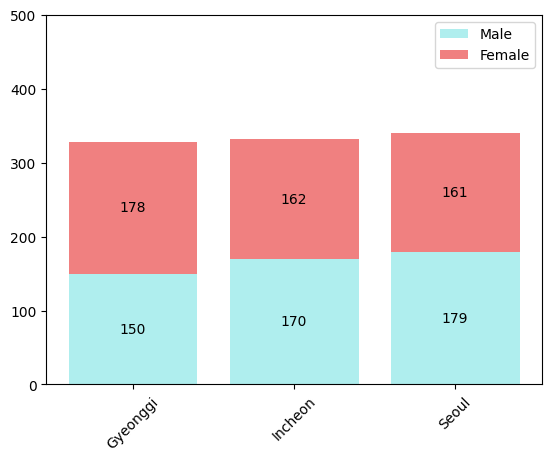

In [43]:
fig, ax = plt.subplots()

bar1 = ax.bar(x=city_gender.index, height=city_gender['Male'], color='paleturquoise', label='Male')
bar2 = ax.bar(x=city_gender.index, height=city_gender['Female'], bottom=city_gender['Male'], color='lightcoral', label='Female')

ax.bar_label(bar1, label_type='center')  # 글자 넣는것 
ax.bar_label(bar2, label_type='center')  # 글자 넣는것 

plt.ylim(0, 500)
plt.xticks(rotation=45)
plt.legend()
plt.show()

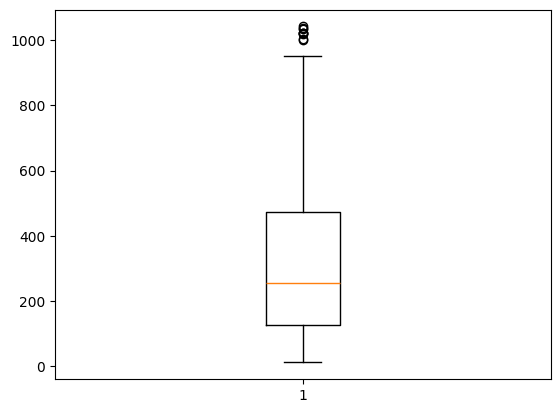

In [44]:
plt.boxplot(df['TOTAL_PRICE'])
plt.show()

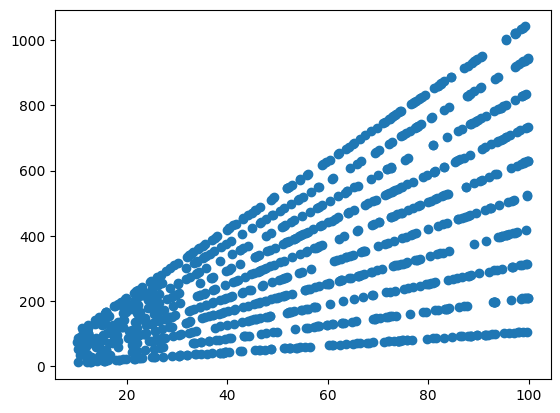

In [45]:
plt.scatter(df['UNIT_PRICE'], df['TOTAL_PRICE'])
plt.show()

In [47]:
man = df[df['GENDER'] == 'Male']
woman = df[df['GENDER'] == 'Female']

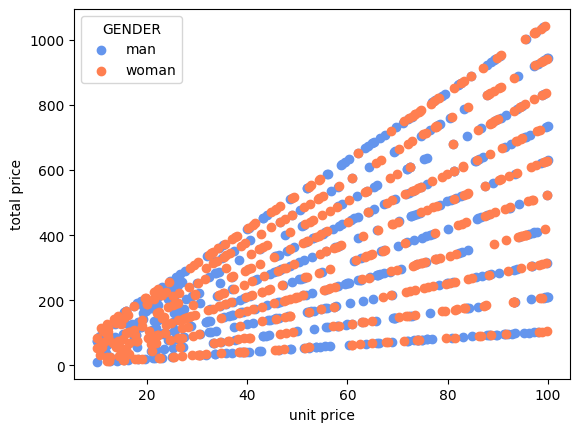

In [51]:
plt.scatter(man['UNIT_PRICE'], man['TOTAL_PRICE'], color='cornflowerblue', label='man')
plt.scatter(woman['UNIT_PRICE'], woman['TOTAL_PRICE'], color='coral', label='woman')
plt.legend(title='GENDER')
plt.xlabel('unit price')
plt.ylabel('total price')
plt.show()

In [52]:
category_counts = df['CITY'].value_counts()
print(category_counts)

CITY
Seoul       340
Incheon     332
Gyeonggi    328
Name: count, dtype: int64


In [53]:
city_idx = category_counts.index
print(city_idx)

Index(['Seoul', 'Incheon', 'Gyeonggi'], dtype='object', name='CITY')


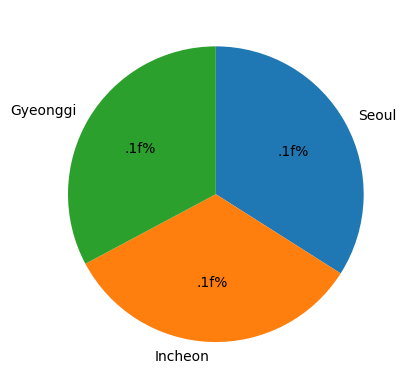

In [55]:
plt.pie(category_counts, labels=city_idx, autopct=".1f%%", startangle=90, counterclock=False)
plt.show()

In [56]:
city_list = list(category_counts.index)
expl = [] 
for city in city_list:
    if city == 'Seoul':
        expl.append(0.1)
    else:
        expl.append(0)

In [57]:
expl

[0.1, 0, 0]

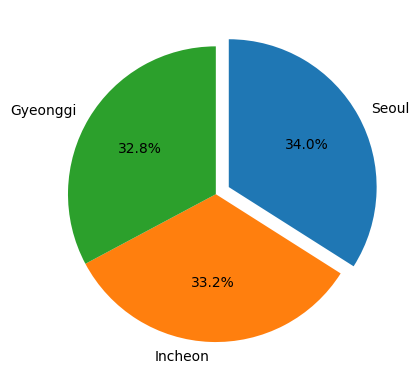

In [61]:
plt.pie(category_counts, labels=city_idx, autopct="%.1f%%", startangle=90, counterclock=False, explode = expl)
plt.show()

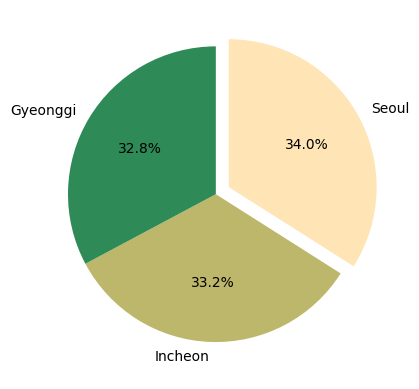

In [62]:
pie_color = ['moccasin', 'darkkhaki', 'seagreen']
plt.pie(category_counts, labels=city_idx, autopct="%.1f%%", startangle=90, 
        counterclock=False, explode = expl, colors=pie_color)
plt.show()

### seaborn  
- 단점은 matplotlib에 비해 커스텀화 하기가 어렵다 

In [63]:
len(df)

1000

In [64]:
import seaborn as sns 

<Axes: xlabel='TOTAL_PRICE', ylabel='Count'>

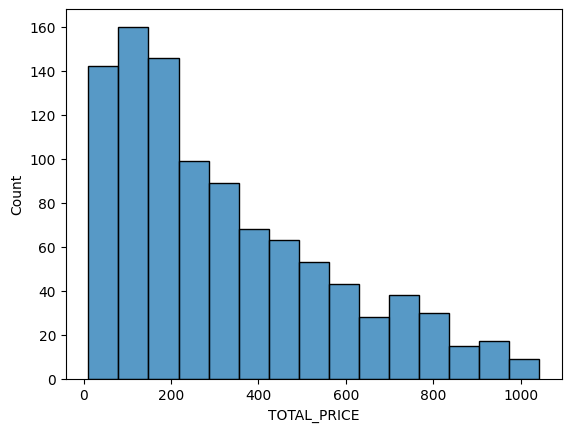

In [65]:
sns.histplot(data=df, x = 'TOTAL_PRICE')

<Axes: xlabel='TOTAL_PRICE', ylabel='Percent'>

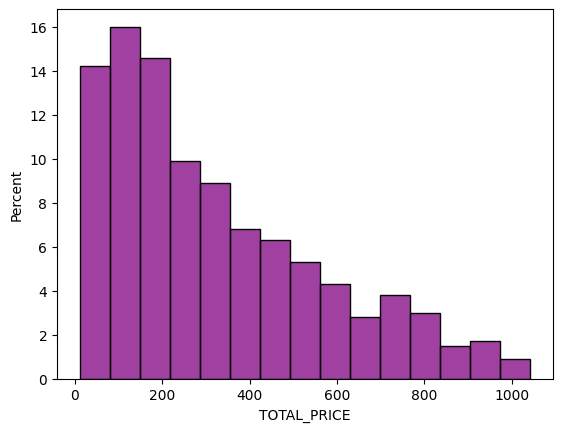

In [66]:
sns.histplot(data=df, x='TOTAL_PRICE', stat='percent', color='purple')

<Axes: xlabel='TOTAL_PRICE', ylabel='Count'>

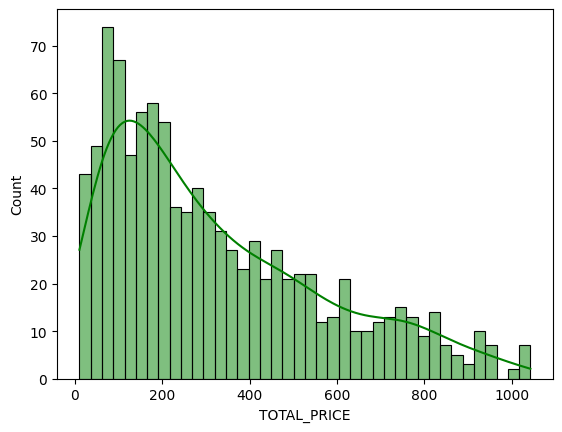

In [67]:
sns.histplot(data=df, x='TOTAL_PRICE', color='green', bins=40, kde=True)

<Axes: xlabel='TOTAL_PRICE', ylabel='Count'>

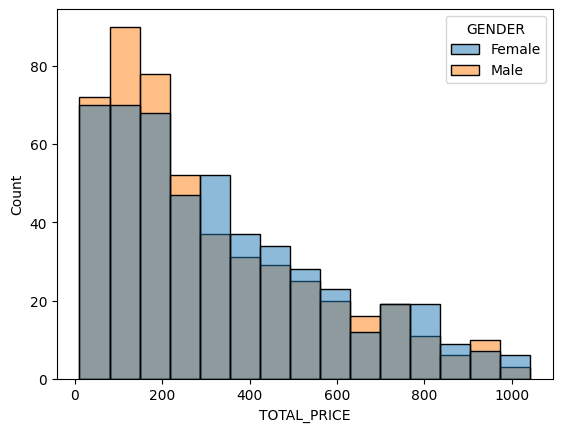

In [68]:
sns.histplot(data=df, x='TOTAL_PRICE', hue='GENDER')

<Axes: xlabel='CITY', ylabel='count'>

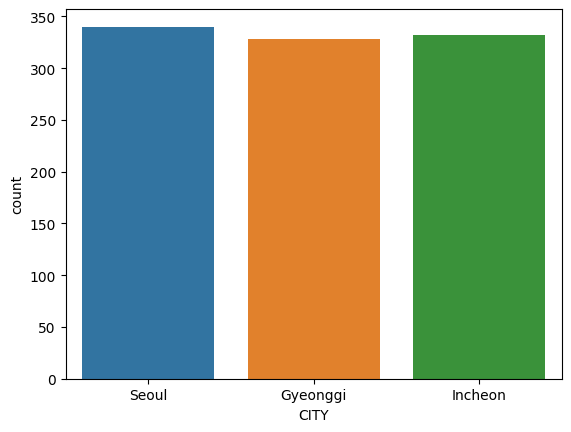

In [78]:
sns.countplot(data=df, x='CITY', hue='CITY')

C:\Users\User\AppData\Local\Temp\ipykernel_6816\3394221628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CITY', palette=palette1)


<Axes: xlabel='CITY', ylabel='count'>

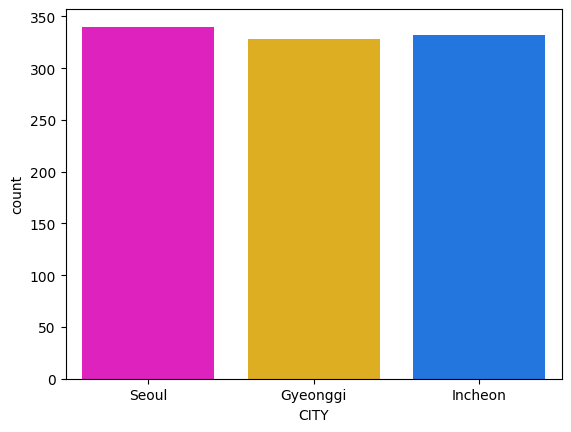

In [70]:
colors = ['#fc03d3', '#fcbe03', '#0373fc']
palette1 = sns.color_palette(colors)
sns.countplot(data=df, x='CITY', palette=palette1)

<Axes: xlabel='CITY', ylabel='count'>

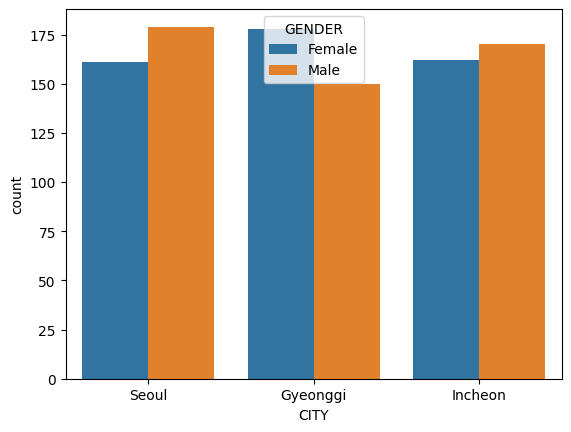

In [72]:
sns.countplot(data=df, x='CITY', hue='GENDER')

<Axes: xlabel='CITY', ylabel='count'>

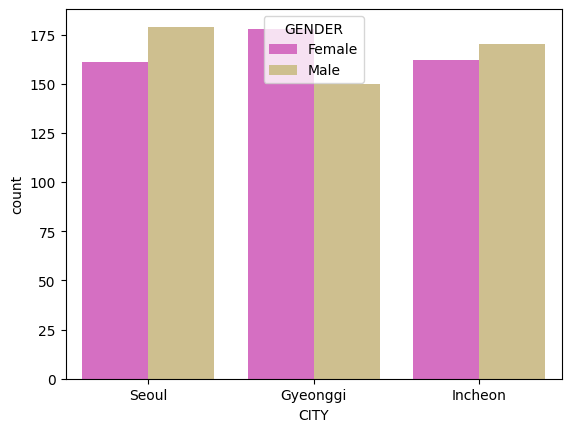

In [74]:
colors = ['#e65ecd', '#d9c584']
palette1 = sns.color_palette(colors)
sns.countplot(data=df, x='CITY', hue='GENDER', palette=palette1)

<Axes: ylabel='TOTAL_PRICE'>

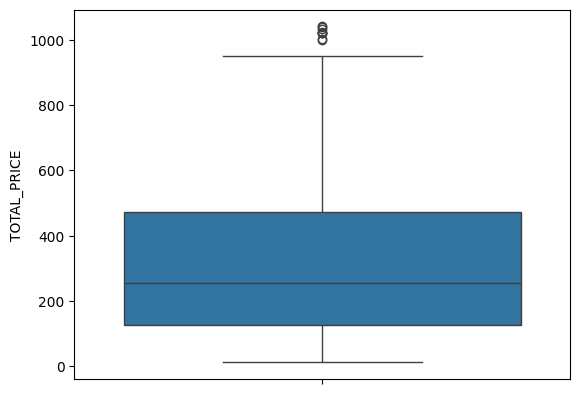

In [75]:
sns.boxplot(data=df, y='TOTAL_PRICE')

<Axes: xlabel='GENDER', ylabel='TOTAL_PRICE'>

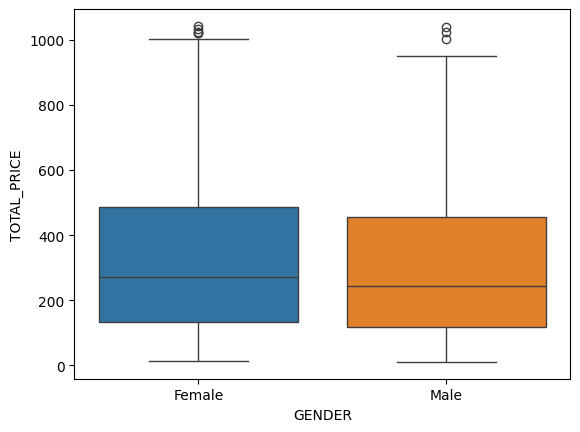

In [77]:
sns.boxplot(data=df, x='GENDER', y='TOTAL_PRICE', hue='GENDER')

<Axes: xlabel='UNIT_PRICE', ylabel='TOTAL_PRICE'>

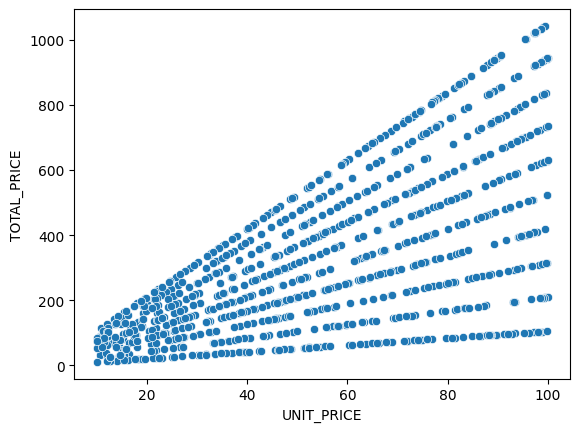

In [79]:
sns.scatterplot(data=df, x='UNIT_PRICE', y='TOTAL_PRICE')

<Axes: xlabel='UNIT_PRICE', ylabel='TOTAL_PRICE'>

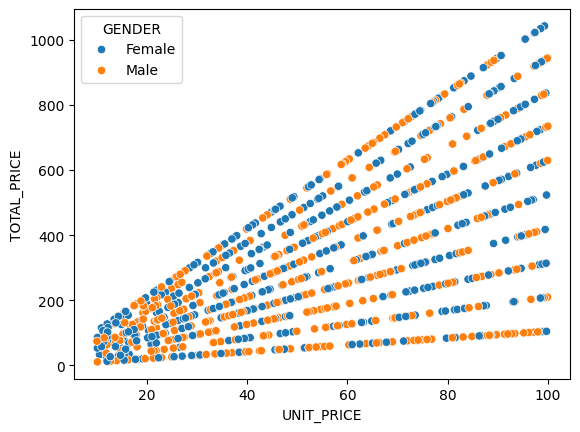

In [80]:
sns.scatterplot(data=df, x='UNIT_PRICE', y='TOTAL_PRICE', hue='GENDER')

<Axes: xlabel='UNIT_PRICE', ylabel='TOTAL_PRICE'>

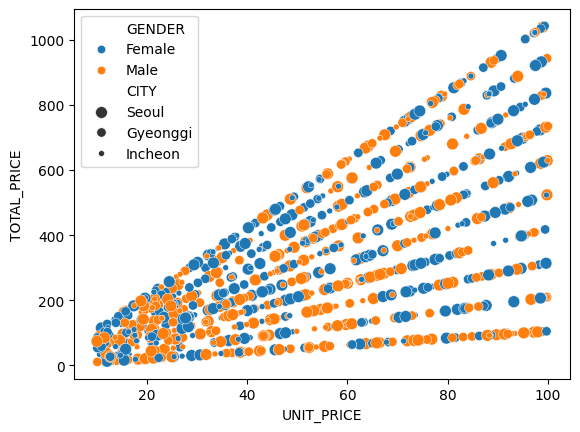

In [81]:
sns.scatterplot(data=df, x='UNIT_PRICE', y='TOTAL_PRICE', hue='GENDER', size='CITY')

In [82]:
df.CITY.unique()

array(['Seoul', 'Gyeonggi', 'Incheon'], dtype=object)

#### Plotly

In [83]:
import plotly.express as px 

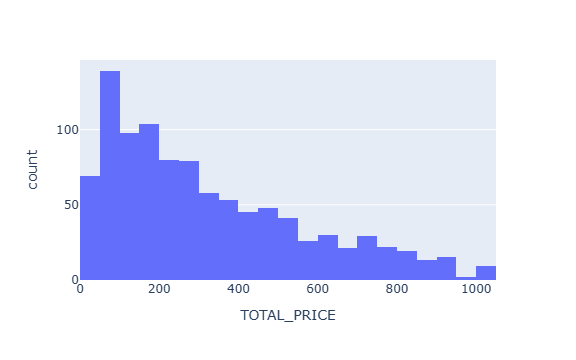

In [84]:
fig = px.histogram(data_frame=df, x='TOTAL_PRICE')
fig.show()

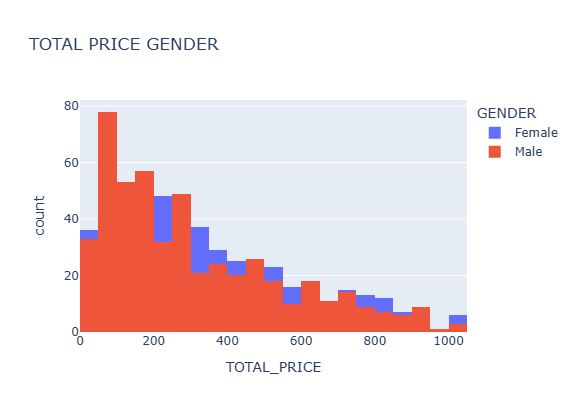

In [85]:
fig = px.histogram(data_frame=df, x='TOTAL_PRICE', color='GENDER', title='TOTAL PRICE GENDER')
fig.update_layout(barmode='overlay', width=600, height=400)
fig.show()

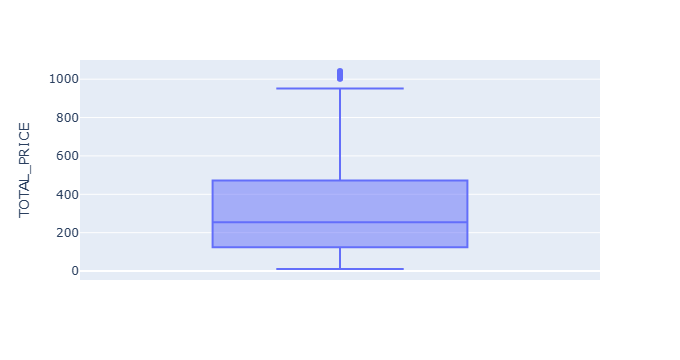

In [86]:
fig = px.box(data_frame=df, y='TOTAL_PRICE')
fig.show()

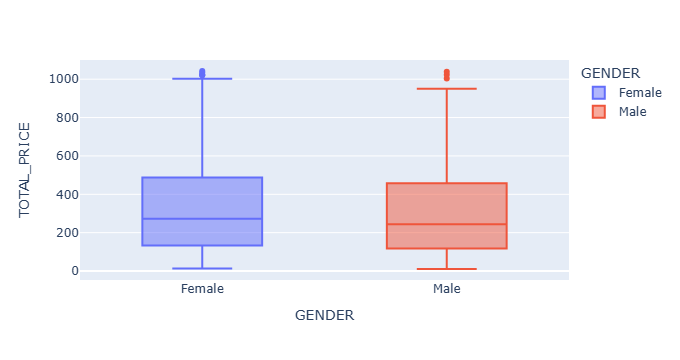

In [87]:
fig = px.box(data_frame=df, x='GENDER', y='TOTAL_PRICE', color='GENDER')
fig.show()

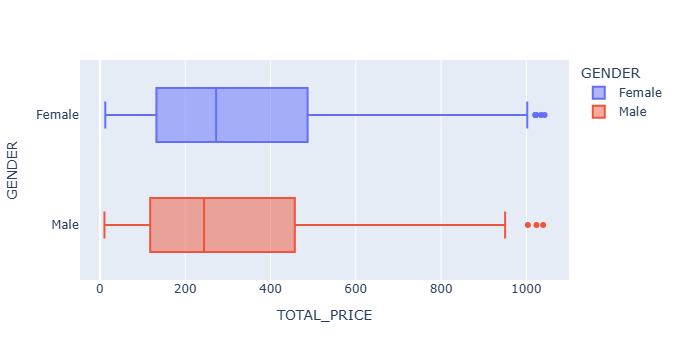

In [88]:
fig = px.box(data_frame=df, x='TOTAL_PRICE', y='GENDER', color='GENDER')
fig.show()

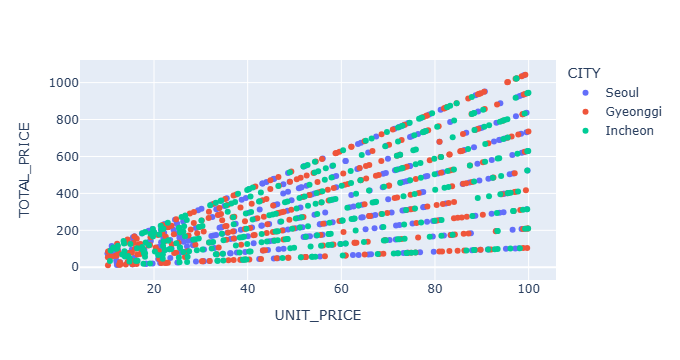

In [89]:
fig = px.scatter(data_frame=df, x='UNIT_PRICE', y='TOTAL_PRICE', color='CITY')
fig.show()

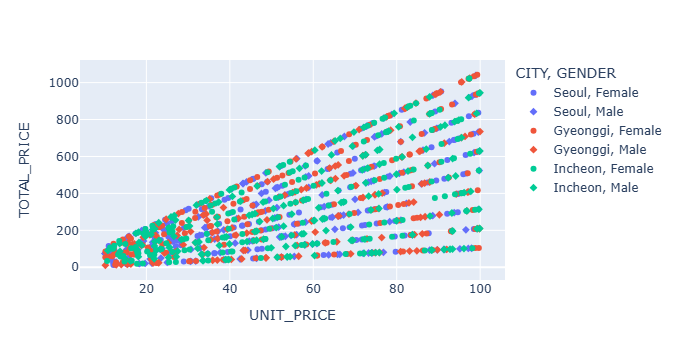

In [90]:
fig = px.scatter(data_frame=df, x='UNIT_PRICE', y='TOTAL_PRICE', color='CITY', symbol='GENDER')
fig.show()

In [93]:
category_counts = df['CITY'].value_counts().reset_index()
category_counts.columns = ['city', 'freq']
print(category_counts)

       city  freq
0     Seoul   340
1   Incheon   332
2  Gyeonggi   328


#### 파이 차트

- pandas value_counts 결과로 그리는 방법 

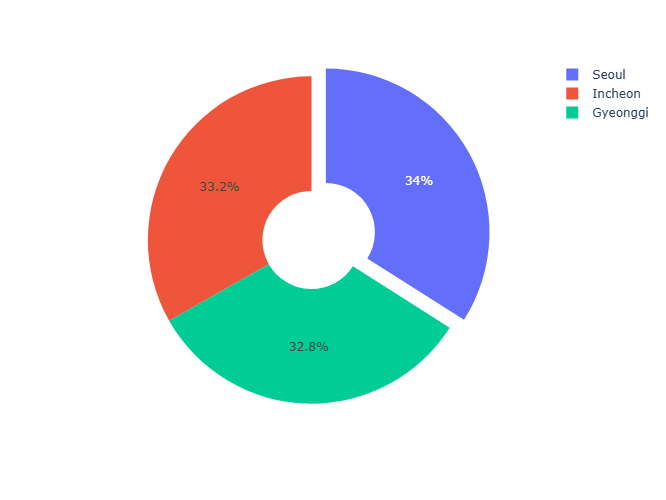

In [94]:
fig = px.pie(data_frame = category_counts, names='city', values='freq')
fig.update_traces(hole=.3, pull=[0.1, 0, 0])  # hole: 중간에 구멍 뚫어주는 옵션 
fig.update_layout(width=600, height=500)
fig.show()

- 순수 list로 그리는 방법   

In [95]:
count_val = list(df['CITY'].value_counts())
count_val

[340, 332, 328]

In [96]:
count_idx = list(df['CITY'].value_counts().index)
print(count_idx)

['Seoul', 'Incheon', 'Gyeonggi']


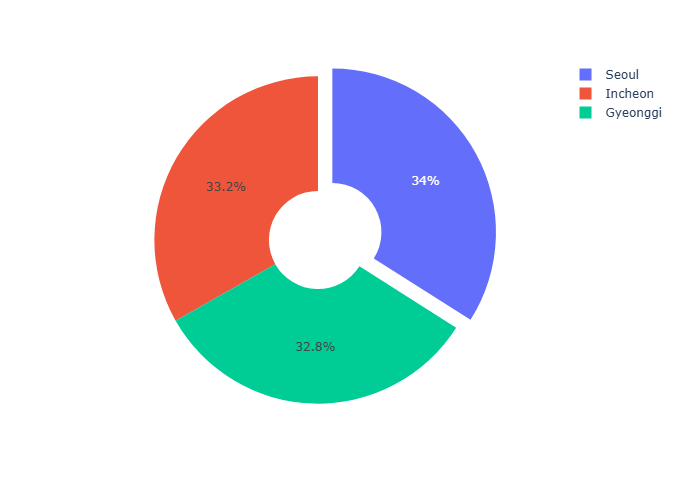

In [97]:
fig = px.pie(names=count_idx, values=count_val)
fig.update_traces(hole=.3, pull = [0.1, 0, 0])
fig.update_layout(width=600, height=500)
fig.show()